# Anomaly Detection — Kickoff Notebook

**Case holder:** Ishkhan Gorgisyan (ESS) · **Team captains:** Charly, Guillermo

This notebook does the same core trick as Monday's Lecture 02 notebook (train an
autoencoder on "normal" waveforms, use reconstruction error as an anomaly score) but on
**real ESS LLRF data** instead of a clean synthetic one. Real data is messier: there's no
confirmed fault label, and the raw signal doesn't quite behave the way its own field names
suggest. Both of those surprises are part of the notebook, not bugs to hide.

What's here:
1. Load a real sample of ESS `SDS_Data` events
2. A first look at the raw waveform — and a naming surprise worth flagging to the case holder
3. Feature engineering (physics-informed + statistical descriptors, scaled down from the
   SPIRAL2 LLRF pipeline's approach — see pointers at the end)
4. Unsupervised anomaly detection: autoencoder + reconstruction error (no ground truth, so
   evaluation is score-distribution/visual, not ROC-AUC like Monday)
5. A weakly-supervised bonus angle, with explainability via **SHAP** and **LIME**
6. A stretch pointer to the slow EPICS archiver data, for precursor-style analysis

## Before you start

The full raw archive (71GB+ of `SDS_Data`/`Archiver_Data` tars) is **not in this
repository** — it lives on CC-IN2P3 storage at
`/sps/m4cast/artifact_hackathon_2026/anomaly-detection/raw/` (see the
[access guide](../../access-guide.md) for CC-IN2P3 account setup). This notebook runs
entirely on a small real sample in `data/sample/ess_llrf_sample.parquet` (210 events,
~0.5MB, built from that raw archive), so it works straight from a clone.

```
pip install -r requirements.txt
```

Autoencoder training is the slow part — a few minutes on a laptop CPU.

## 1. Setup

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore", category=FutureWarning)
torch.manual_seed(42)
np.random.seed(42)
print("Imports OK")

Imports OK


## 2. Load a real sample of ESS LLRF data

Each row is one `SDS_Data` diagnostic (`DD`) capture: a single RF chain, one acquisition
cycle. `trig_code` looks like the EVR trigger/interlock code — i.e. *why* that capture was
taken — and does vary (14 vs 15 in this sample), correlated with `beam_mode`/`beam_state`.
That makes it a plausible weak label, **but it is not a confirmed fault label**: the case
holder hasn't published the scientific case yet, so treat any split on `trig_code` here as
exploratory, not ground truth.

In [2]:
CANDIDATES = [
    os.path.join("data", "sample", "ess_llrf_sample.parquet"),
    os.path.join("..", "anomaly-detection", "data", "sample", "ess_llrf_sample.parquet"),
]
SAMPLE_PATH = next((c for c in CANDIDATES if os.path.exists(c)), CANDIDATES[0])

df = pd.read_parquet(SAMPLE_PATH)
print(f"Loaded {len(df)} events from {SAMPLE_PATH}")
print(df[["trig_code", "beam_mode", "beam_state"]].value_counts())

Loaded 210 events from data/sample/ess_llrf_sample.parquet
trig_code  beam_mode          beam_state           
15         RfTest             BEAM_PRESENT_YES         95
14         Probe              BEAM_INHIBIT             20
15         RfTest             BEAM_INHIBIT             20
           Probe              BEAM_PRESENT_YES         15
                              BEAM_INHIBIT             15
           SlowCommissioning  BEAM_INHIBIT             15
                              BEAM_PRESENT_YES         15
                              BEAM_INHIBIT_SOFTWARE    10
                              BEAM_PRESENT_NO           5
Name: count, dtype: int64


## 3. First look at the raw waveform — and a real-data surprise

ESS labels the two components of each capture `Cmp0` and `Cmp1`, which reads like a
classic I/Q quadrature pair. Let's not assume that and just plot them.

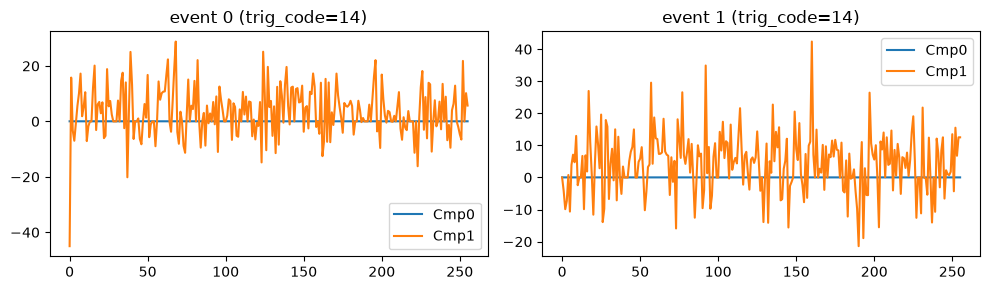

Cmp0 per-event std (first 5): [0.00066 0.0006  0.00057 0.00069 0.00059]
Cmp1 per-event std (first 5): [8.82 9.23 9.14 9.82 8.79]


In [3]:
cmp0 = np.stack(df["I"].to_numpy())  # "Cmp0" component
cmp1 = np.stack(df["Q"].to_numpy())  # "Cmp1" component

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for k, ax in enumerate(axes):
    ax.plot(cmp0[k], label="Cmp0")
    ax.plot(cmp1[k], label="Cmp1")
    ax.set_title(f"event {k} (trig_code={df['trig_code'].iloc[k]})")
    ax.legend()
plt.tight_layout()
plt.show()

print("Cmp0 per-event std (first 5):", cmp0.std(axis=1)[:5].round(5))
print("Cmp1 per-event std (first 5):", cmp1.std(axis=1)[:5].round(2))

`Cmp0` is essentially flat (std ~6e-4) in every event, while `Cmp1` carries all the real
RF dynamics. So despite the I/Q-sounding name, this isn't a standard quadrature pair in
this sample — **ask Ishkhan to confirm what `Cmp0`/`Cmp1` actually are** before relying on
that naming. From here on we use `Cmp1` as the primary waveform, and keep `Cmp0`'s mean as
one extra feature in case it does carry signal (a per-event calibration offset, maybe).

## 4. Feature engineering

A scaled-down version of the SPIRAL2 LLRF pipeline's approach (physics-informed +
general statistical/temporal descriptors), computed per event on `Cmp1`: amplitude
range, rate-of-change, spectral peak, and standard moments. This is the matrix the rest
of the notebook uses — not the raw waveform directly.

In [4]:
def engineer_features(wave, cmp0_ref):
    feats = {"cmp0_mean": cmp0_ref.mean(axis=1)}
    feats["mean"] = wave.mean(axis=1)
    feats["std"] = wave.std(axis=1)
    feats["min"] = wave.min(axis=1)
    feats["max"] = wave.max(axis=1)
    feats["ptp"] = wave.max(axis=1) - wave.min(axis=1)

    c = wave - wave.mean(axis=1, keepdims=True)
    s = wave.std(axis=1) + 1e-12
    feats["skew"] = (c ** 3).mean(axis=1) / s ** 3
    feats["kurt"] = (c ** 4).mean(axis=1) / s ** 4 - 3.0

    dwdt = np.diff(wave, axis=1)
    feats["dwdt_std"] = dwdt.std(axis=1)
    feats["dwdt_max"] = np.abs(dwdt).max(axis=1)

    spec = np.abs(np.fft.rfft(wave - wave.mean(axis=1, keepdims=True), axis=1))
    feats["fft_peak_bin"] = spec.argmax(axis=1)
    feats["fft_peak_mag"] = spec.max(axis=1)
    return pd.DataFrame(feats)


X_feat = engineer_features(cmp1, cmp0)
print(f"Feature matrix: {X_feat.shape}")
X_feat.head()

Feature matrix: (210, 12)


,cmp0_mean,mean,std,min,max,ptp,skew,kurt,dwdt_std,dwdt_max,fft_peak_bin,fft_peak_mag
0,0.032672,3.348597,8.818413,-45.000126,28.787773,73.787899,-0.357538,2.898654,12.366316,60.796044,54,343.757394
1,0.032665,4.366801,9.226841,-21.409805,42.385976,63.795781,0.247215,1.187527,12.738431,38.802438,22,389.882301
2,0.032687,2.867626,9.136387,-22.380916,31.046790,53.427706,0.225862,0.047080,12.360099,40.101369,90,367.236072
3,0.032705,3.716740,9.823045,-30.095507,38.243814,68.339321,0.244373,1.220787,14.381728,61.058449,73,436.010428
4,0.032681,3.889458,8.786702,-20.201881,37.680993,57.882874,0.501810,0.888140,12.485008,35.328749,30,315.475678


## 5. Unsupervised anomaly detection — autoencoder on the raw waveform

Same idea as Monday: a small 1-D convolutional autoencoder, trained to reconstruct the
waveform, with reconstruction error as the anomaly score. **Unlike Monday, we have no
confirmed labels**, so the model trains on *all* events (the majority pattern implicitly
plays the role of "normal"), and evaluation is a score distribution and a look at the
top-scored events — not a ROC curve.

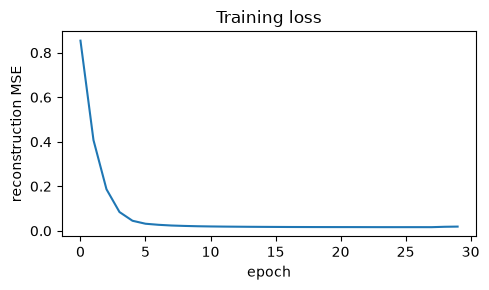

In [5]:
X_wave = cmp1[:, None, :].astype(np.float32)  # (N, 1, 256)
mu = X_wave.mean(axis=(0, 2), keepdims=True)
sigma = X_wave.std(axis=(0, 2), keepdims=True) + 1e-8
X_wave_n = (X_wave - mu) / sigma


class RFAutoencoder(nn.Module):
    # 1-D convolutional autoencoder for single-channel waveform anomaly detection.
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=8, stride=4, padding=2),
            nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(64 * 32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 32),
            nn.Unflatten(1, (64, 32)),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose1d(32, 1, kernel_size=8, stride=4, padding=2),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


model = RFAutoencoder()
loader = DataLoader(TensorDataset(torch.tensor(X_wave_n)), batch_size=32, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
train_losses = []
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        recon = model(batch)
        loss = nn.functional.mse_loss(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    train_losses.append(epoch_loss / len(X_wave_n))

plt.figure(figsize=(5, 3))
plt.plot(train_losses)
plt.xlabel("epoch"); plt.ylabel("reconstruction MSE"); plt.title("Training loss")
plt.tight_layout(); plt.show()

In [6]:
model.eval()
with torch.no_grad():
    recon = model(torch.tensor(X_wave_n))
    anomaly_score = ((torch.tensor(X_wave_n) - recon) ** 2).mean(dim=(1, 2)).numpy()

df["anomaly_score"] = anomaly_score
print(df.groupby("trig_code")["anomaly_score"].describe()[["count", "mean", "std"]])

print("\nTop-5 highest-scored events (exploratory, not a validated fault list):")
df.nlargest(5, "anomaly_score")[["trig_code", "beam_mode", "anomaly_score"]]

           count      mean       std
trig_code                           
14          20.0  0.057124  0.006170
15         190.0  0.014351  0.015587

Top-5 highest-scored events (exploratory, not a validated fault list):


,trig_code,beam_mode,anomaly_score
130,15,SlowCommissioning,0.073370
7,14,Probe,0.069334
9,14,Probe,0.069048
3,14,Probe,0.063364
12,14,Probe,0.062611


## 6. Bonus: a weakly-supervised angle + explainability

If `trig_code` does turn out to be a meaningful operational label, here's what a simple
classifier on the engineered features picks up — and SHAP/LIME to see *why*, exactly the
explainability layer the SPIRAL2 pipeline uses (there: SHAP + LIME on an 810-feature
matrix; here, the same idea on 12 features).

In [7]:
y = df["trig_code"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
clf.fit(X_train.to_numpy(), y_train)
print(f"RF accuracy (trig_code group, {len(X_test)} held-out events): {clf.score(X_test.to_numpy(), y_test):.3f}")
print("Near-ceiling accuracy here likely means trig_code tracks an operating-mode distinction")
print("(RfTest/Probe/SlowCommissioning), not necessarily a subtle fault signal — worth asking Ishkhan.")

RF accuracy (trig_code group, 53 held-out events): 1.000
Near-ceiling accuracy here likely means trig_code tracks an operating-mode distinction
(RfTest/Probe/SlowCommissioning), not necessarily a subtle fault signal — worth asking Ishkhan.


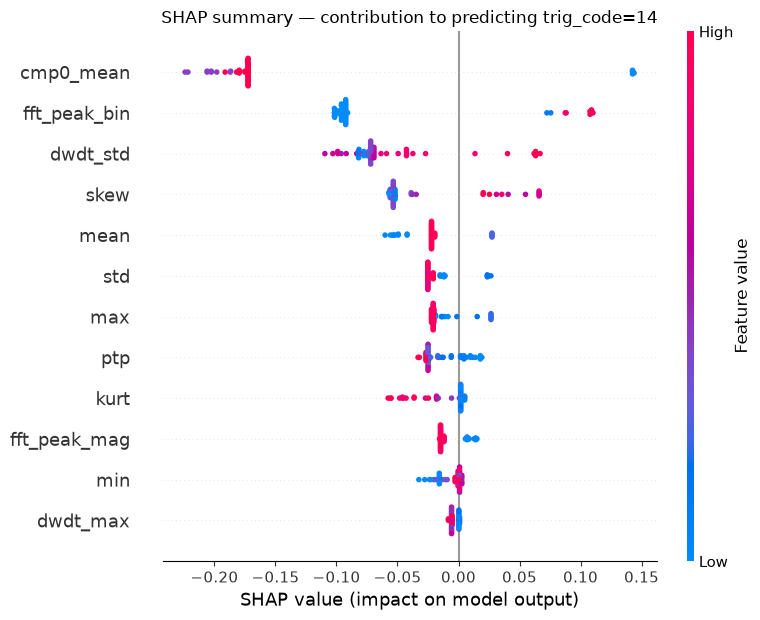

In [8]:
explainer = shap.TreeExplainer(clf)
shap_values = np.asarray(explainer.shap_values(X_test.to_numpy()))

# binary classifier -> shap_values is (n_samples, n_features, n_classes); pick one class
class_idx = list(clf.classes_).index(14)
shap_values_plot = shap_values[:, :, class_idx] if shap_values.ndim == 3 else shap_values

shap.summary_plot(shap_values_plot, X_test, show=False)
plt.title("SHAP summary — contribution to predicting trig_code=14")
plt.tight_layout(); plt.show()

In [9]:
lime_explainer = LimeTabularExplainer(
    X_train.to_numpy(),
    feature_names=list(X_feat.columns),
    class_names=[str(c) for c in sorted(set(y))],
    mode="classification",
)

idx = 0  # swap for any row of X_test you want to inspect
exp = lime_explainer.explain_instance(
    X_test.iloc[idx].to_numpy(), clf.predict_proba, num_features=8
)
print(f"LIME explanation for test event {idx} (true trig_code={y_test[idx]}):")
for feat, weight in exp.as_list():
    print(f"  {feat:30s} {weight:+.4f}")

LIME explanation for test event 0 (true trig_code=15):
  fft_peak_bin <= 1.00           +0.1383
  cmp0_mean <= 4.26              -0.0639
  skew > -0.73                   -0.0543
  std <= 19.70                   -0.0249
  max <= 93.11                   -0.0238
  mean <= 74.06                  -0.0230
  6.06 < dwdt_std <= 9.43        +0.0190
  kurt > 1.58                    +0.0171


## 7. Stretch — slow EPICS archiver data

`Archiver_Data` on the raw store holds slow EPICS trends (`RF_DET_Q_W`, `MAGNETS`,
`RF_PWR_FLD`, `LLRF_1`, ...) around the same time windows as the fast `SDS_Data` events
above. That's the ESS analog of the SPIRAL2 pipeline's **EPICS slow-archiver precursor
investigation** (their "Precursor Root-Cause Atlas") — looking for slow trends that
*precede* a trigger, rather than just describing the triggered event itself. Needs
CC-IN2P3 access to the raw archive; not covered in this notebook, but it's where the
harder objectives in `objectives.md` are headed.

## Next steps

- See `objectives.md` for the easy / medium / hard objectives
- Open question worth raising with Ishkhan: what `Cmp0`/`Cmp1` and `trig_code` actually
  mean — both were inferred from field names here, not confirmed
- Going deeper: this notebook deliberately stays light. The SPIRAL2 LLRF pipeline this
  was adapted from runs the full version of this idea — 810 features, 5 modeling tasks,
  a dedicated explainability layer — on a *different* accelerator (SPIRAL2, not ESS), so
  nothing there is directly portable, but the structure is a good reference:
  - [LLRF_SP2_pipeline](https://github.com/aghribi/LLRF_SP2_pipeline) — the production pipeline
  - [LLRF_SP2_report](https://github.com/aghribi/LLRF_SP2_report) — the companion paper source